# 🔬 Backbone Comparison: MobileNetV2 vs VGG-16 vs ResNet50
## Avenue Dataset — Anomaly Detection Pipeline

| Metric | MobileNetV2 | VGG-16 | ResNet50 |
|--------|-------------|--------|----------|
| Params | ~3.4 M | ~14.7 M | ~23.5 M |
| Model size | ~13 MB | ~56 MB | ~90 MB |
| Feature dim (GAP) | 1280 | 512 | 2048 |
| Architecture | Depthwise sep conv | Plain conv blocks | Residual skip conn |
| Preprocessing | Scale [-1, 1] | BGR mean subtraction | Scale [-1, 1] |

> This notebook builds all three extractors, measures parameters, model size, feature dims,  
> inference speed, and LSTM pipeline totals — then generates 7 comparison plots + a radar chart.

## Cell 1 — Install & Import Libraries

In [1]:
# !pip install tensorflow opencv-python matplotlib scikit-learn tqdm numpy pandas seaborn

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2, VGG16, ResNet50
from tensorflow.keras.applications.mobilenet_v2  import preprocess_input as preprocess_mn
from tensorflow.keras.applications.vgg16         import preprocess_input as preprocess_vgg
from tensorflow.keras.applications.resnet50      import preprocess_input as preprocess_rn

np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

TensorFlow : 2.18.0
GPU        : []


## Cell 2 — Configuration

In [2]:
IMG_H, IMG_W = 224, 224
BATCH_SIZE   = 16      # for speed benchmark
N_BATCHES    = 10      # number of batches to time
SAVE_DIR     = '.'     # where to save plots / CSV

os.makedirs(SAVE_DIR, exist_ok=True)

print('=' * 65)
print('  BACKBONE COMPARISON: MobileNetV2 | VGG-16 | ResNet50')
print('=' * 65)
print(f'  Image size  : {IMG_H}x{IMG_W}')
print(f'  Benchmark   : {BATCH_SIZE} imgs x {N_BATCHES} batches')
print(f'  Save dir    : {os.path.abspath(SAVE_DIR)}')

  BACKBONE COMPARISON: MobileNetV2 | VGG-16 | ResNet50
  Image size  : 224x224
  Benchmark   : 16 imgs x 10 batches
  Save dir    : C:\Users\awati\Avenue_Dataset 3\Avenue Dataset


## Cell 3 — Build All Three Feature Extractors

> All backbones use **frozen ImageNet weights** + `GlobalAveragePooling2D`  
> Each produces a fixed-dim vector per frame used as LSTM input.

In [3]:
def build_extractor(backbone_cls, preprocess_fn, name):
    base = backbone_cls(
        input_shape=(IMG_H, IMG_W, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False
    inp = Input(shape=(IMG_H, IMG_W, 3))
    x   = preprocess_fn(inp)
    x   = base(x, training=False)
    x   = GlobalAveragePooling2D()(x)
    return Model(inp, x, name=name)


print('Building extractors (downloading ImageNet weights if needed)...')
extractor_mn  = build_extractor(MobileNetV2, preprocess_mn,  'MobileNetV2_Extractor')
extractor_vgg = build_extractor(VGG16,       preprocess_vgg, 'VGG16_Extractor')
extractor_rn  = build_extractor(ResNet50,    preprocess_rn,  'ResNet50_Extractor')
print('  ✅ All three extractors built.')

Building extractors (downloading ImageNet weights if needed)...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
  ✅ All three extractors built.


## Cell 4 — Parameter Count

In [4]:
def count_params(model):
    total     = model.count_params()
    trainable = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
    frozen    = total - trainable
    return total, trainable, frozen


params = {}
print(f'  {"Model":<14}  {"Total":>10}  {"Trainable":>10}  {"Frozen":>10}')
print('  ' + '-'*50)
for name, ext in [("MobileNetV2", extractor_mn),
                   ("VGG-16",      extractor_vgg),
                   ("ResNet50",    extractor_rn)]:
    total, train, frozen = count_params(ext)
    params[name] = {'Total': total, 'Trainable': train, 'Frozen': frozen}
    print(f'  {name:<14}  {total/1e6:>8.2f} M  {train:>10,}  {frozen/1e6:>8.2f} M')

  Model                Total   Trainable      Frozen
  --------------------------------------------------
  MobileNetV2         2.26 M           0      2.26 M
  VGG-16             14.71 M           0     14.71 M
  ResNet50           23.59 M           0     23.59 M


## Cell 5 — Model Size on Disk

In [5]:
print('Measuring model sizes on disk (save → stat → delete)...')
sizes_mb = {}
for name, ext in [("MobileNetV2", extractor_mn),
                   ("VGG-16",      extractor_vgg),
                   ("ResNet50",    extractor_rn)]:
    path = os.path.join(SAVE_DIR, f'_tmp_{name.replace("-","")}.keras')
    ext.save(path)
    mb = os.path.getsize(path) / (1024 ** 2)
    sizes_mb[name] = round(mb, 2)
    os.remove(path)
    print(f'  {name:<14}  {mb:.2f} MB')

Measuring model sizes on disk (save → stat → delete)...
  MobileNetV2     9.14 MB
  VGG-16          56.21 MB
  ResNet50        90.58 MB


## Cell 6 — Feature Vector Dimensions (GAP Output)

In [6]:
feat_dims = {
    'MobileNetV2': extractor_mn.output_shape[-1],
    'VGG-16':      extractor_vgg.output_shape[-1],
    'ResNet50':    extractor_rn.output_shape[-1],
}

print('Feature dimensions after GlobalAveragePooling2D:')
for name, dim in feat_dims.items():
    print(f'  {name:<14}  {dim}-dim')

print(f'\nLSTM input shapes:')
for name, dim in feat_dims.items():
    print(f'  {name:<14}  (batch, 16, {dim})')

Feature dimensions after GlobalAveragePooling2D:
  MobileNetV2     1280-dim
  VGG-16          512-dim
  ResNet50        2048-dim

LSTM input shapes:
  MobileNetV2     (batch, 16, 1280)
  VGG-16          (batch, 16, 512)
  ResNet50        (batch, 16, 2048)


## Cell 7 — Inference Speed Benchmark

> Times `N_BATCHES × BATCH_SIZE` forward passes per model  
> Reports **ms per image** (lower = faster)

In [7]:
print(f'Benchmarking inference speed ({BATCH_SIZE} imgs x {N_BATCHES} batches)...')
dummy = np.random.rand(BATCH_SIZE, IMG_H, IMG_W, 3).astype(np.float32)

inference_times = {}
for name, ext in [("MobileNetV2", extractor_mn),
                   ("VGG-16",      extractor_vgg),
                   ("ResNet50",    extractor_rn)]:
    ext.predict(dummy[:2], verbose=0)   # warm-up
    t0 = time.time()
    for _ in range(N_BATCHES):
        ext.predict(dummy, verbose=0)
    elapsed = time.time() - t0
    ms_per_img = (elapsed / (N_BATCHES * BATCH_SIZE)) * 1000
    inference_times[name] = round(ms_per_img, 3)
    print(f'  {name:<14}  {ms_per_img:.3f} ms / image')

Benchmarking inference speed (16 imgs x 10 batches)...
  MobileNetV2     53.492 ms / image
  VGG-16          233.323 ms / image
  ResNet50        114.476 ms / image


## Cell 8 — Full Pipeline Parameters (Backbone + LSTM Head)

> Builds the 2-layer LSTM head for each backbone's feature dimension  
> and reports total pipeline param count.

In [8]:
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization

SEQ_LEN = 16

def build_lstm_head(feat_dim, name):
    inp = Input(shape=(SEQ_LEN, feat_dim))
    x   = LSTM(256, return_sequences=True, dropout=0.3)(inp)
    x   = Dropout(0.4)(x)
    x   = LSTM(128, return_sequences=False, dropout=0.2)(x)
    x   = Dropout(0.3)(x)
    x   = Dense(64, activation='relu')(x)
    x   = BatchNormalization()(x)
    x   = Dropout(0.2)(x)
    out = Dense(1, activation='sigmoid')(x)
    return Model(inp, out, name=name)


full_params = {}
print(f'  {"Model":<14}  {"Backbone":>10}  {"LSTM head":>10}  {"Total":>10}')
print('  ' + '-'*50)
for name, dim in feat_dims.items():
    m          = build_lstm_head(dim, name)
    backbone_p = params[name]['Total']
    lstm_p     = m.count_params()
    total_p    = backbone_p + lstm_p
    full_params[name] = {'Backbone': backbone_p, 'LSTM_head': lstm_p, 'Total_pipeline': total_p}
    print(f'  {name:<14}  {backbone_p/1e6:>8.2f} M  {lstm_p/1e3:>8.1f} K  {total_p/1e6:>8.2f} M')

  Model             Backbone   LSTM head       Total
  --------------------------------------------------
  MobileNetV2         2.26 M    1779.6 K      4.04 M
  VGG-16             14.71 M     993.2 K     15.71 M
  ResNet50           23.59 M    2566.0 K     26.15 M


## Cell 9 — Master Summary Table

In [9]:
rows = []
for name in ['MobileNetV2', 'VGG-16', 'ResNet50']:
    rows.append({
        'Model':                     name,
        'Backbone params (M)':       round(params[name]['Total'] / 1e6, 2),
        'Frozen params (M)':         round(params[name]['Frozen'] / 1e6, 2),
        'LSTM head params (K)':      round(full_params[name]['LSTM_head'] / 1e3, 1),
        'Total pipeline params (M)': round(full_params[name]['Total_pipeline'] / 1e6, 2),
        'Model size (MB)':           sizes_mb[name],
        'Feature dim':               feat_dims[name],
        'Inference ms/img':          inference_times[name],
        'Architecture style':        {'MobileNetV2': 'Depthwise sep conv',
                                      'VGG-16':      'Plain conv blocks',
                                      'ResNet50':    'Residual skip conn'}[name],
        'Preprocessing':             {'MobileNetV2': 'Scale [-1,1]',
                                      'VGG-16':      'BGR mean subtract',
                                      'ResNet50':    'Scale [-1,1]'}[name],
        'Depth (layers)':            {'MobileNetV2': 53, 'VGG-16': 23, 'ResNet50': 175}[name],
        'Input size':                '224x224x3',
        'ImageNet top-1 acc':        {'MobileNetV2': 71.8, 'VGG-16': 71.3, 'ResNet50': 74.9}[name],
        'Best use case':             {'MobileNetV2': 'Edge / fast inference',
                                      'VGG-16':      'Baseline / simple arch',
                                      'ResNet50':    'Best accuracy'}[name],
    })

df = pd.DataFrame(rows)
csv_path = os.path.join(SAVE_DIR, 'backbone_comparison.csv')
df.to_csv(csv_path, index=False)

print('MASTER SUMMARY TABLE')
print('=' * 90)
print(df.to_string(index=False))
print(f'\n✅ CSV saved → {csv_path}')

MASTER SUMMARY TABLE
      Model  Backbone params (M)  Frozen params (M)  LSTM head params (K)  Total pipeline params (M)  Model size (MB)  Feature dim  Inference ms/img Architecture style     Preprocessing  Depth (layers) Input size  ImageNet top-1 acc          Best use case
MobileNetV2                 2.26               2.26                1779.6                       4.04             9.14         1280            53.492 Depthwise sep conv      Scale [-1,1]              53  224x224x3                71.8  Edge / fast inference
     VGG-16                14.71              14.71                 993.2                      15.71            56.21          512           233.323  Plain conv blocks BGR mean subtract              23  224x224x3                71.3 Baseline / simple arch
   ResNet50                23.59              23.59                2566.0                      26.15            90.58         2048           114.476 Residual skip conn      Scale [-1,1]             175  224x224x

## Cell 10 — Visualizations (7 Subplots + Radar Chart)

Generates one figure with:
1. Backbone parameter count
2. Model size on disk
3. Feature vector dimension
4. Inference speed (ms/img)
5. Stacked backbone + LSTM head params
6. Network depth (layers)
7. Multi-criteria radar chart

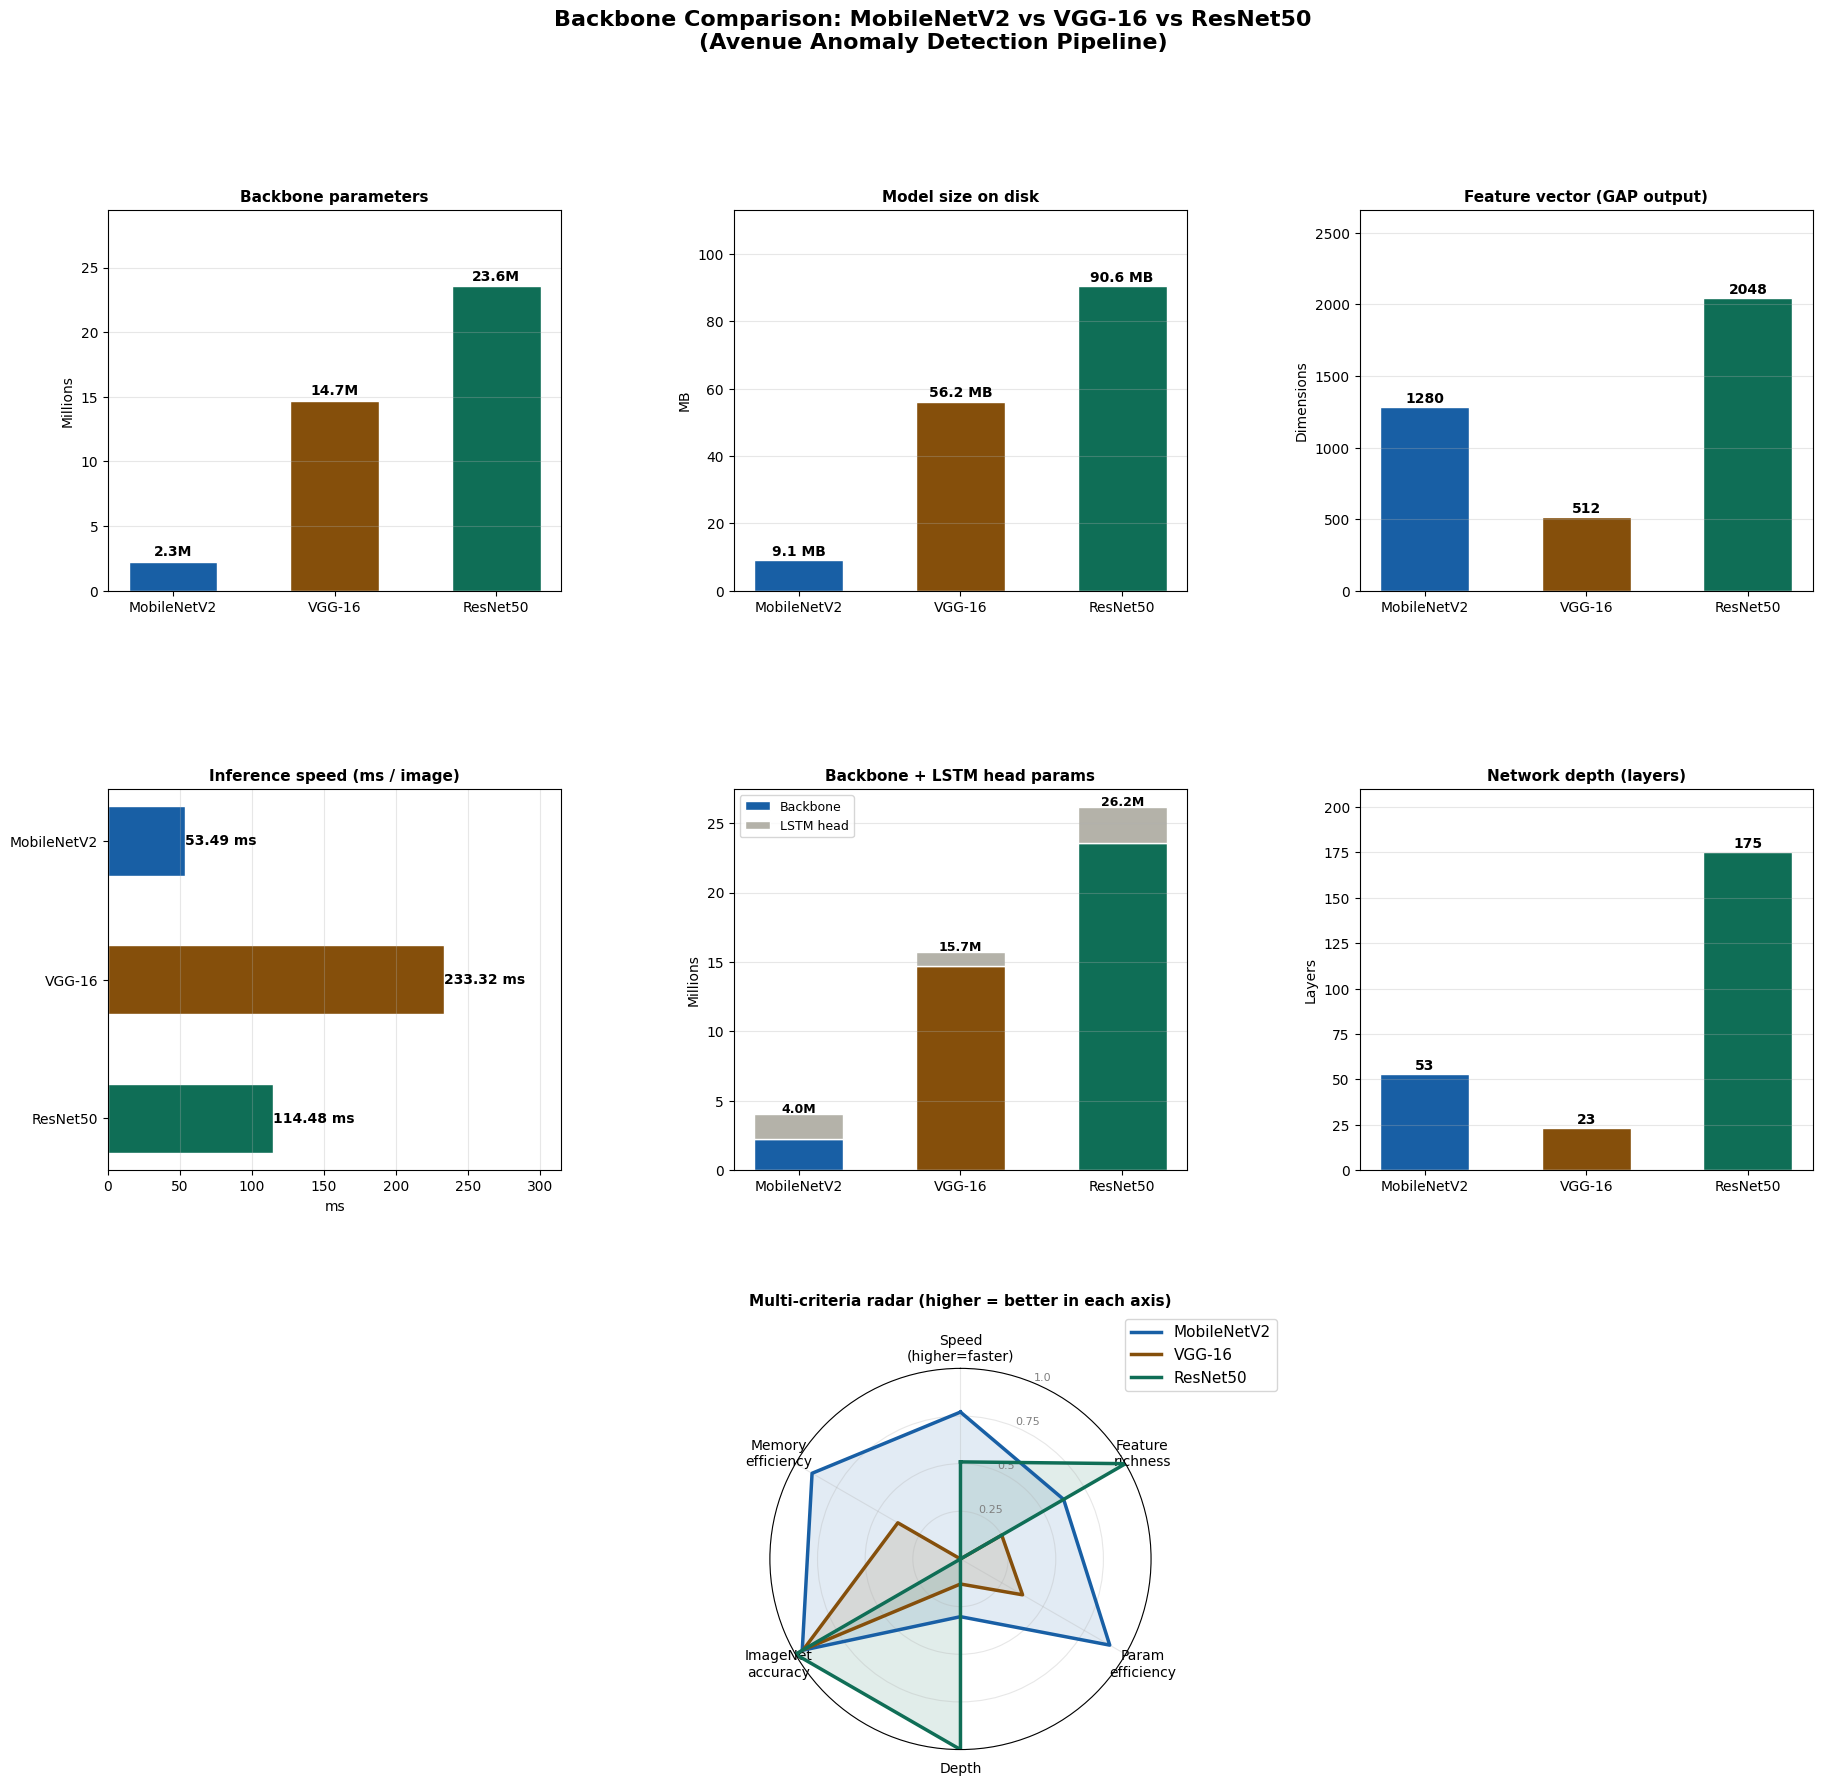

✅ Plot saved → .\backbone_comparison.png


In [10]:
COLORS = {'MobileNetV2': '#185FA5', 'VGG-16': '#854F0B', 'ResNet50': '#0F6E56'}
LABELS = list(COLORS.keys())
COLS   = list(COLORS.values())

fig = plt.figure(figsize=(22, 20))
fig.suptitle(
    'Backbone Comparison: MobileNetV2 vs VGG-16 vs ResNet50\n'
    '(Avenue Anomaly Detection Pipeline)',
    fontsize=16, fontweight='bold', y=0.98
)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.52, wspace=0.38)


# ── Plot 1: Backbone Parameter Count ────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
vals = [params[n]['Total'] / 1e6 for n in LABELS]
bars = ax1.bar(LABELS, vals, color=COLS, edgecolor='white', width=0.55)
for b, v in zip(bars, vals):
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 0.2, f'{v:.1f}M',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_title('Backbone parameters', fontsize=11, fontweight='bold')
ax1.set_ylabel('Millions'); ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, max(vals)*1.25)


# ── Plot 2: Model Size on Disk ──────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
vals2 = [sizes_mb[n] for n in LABELS]
bars2 = ax2.bar(LABELS, vals2, color=COLS, edgecolor='white', width=0.55)
for b, v in zip(bars2, vals2):
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5, f'{v:.1f} MB',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_title('Model size on disk', fontsize=11, fontweight='bold')
ax2.set_ylabel('MB'); ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, max(vals2)*1.25)


# ── Plot 3: Feature Vector Dimension ────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
vals3 = [feat_dims[n] for n in LABELS]
bars3 = ax3.bar(LABELS, vals3, color=COLS, edgecolor='white', width=0.55)
for b, v in zip(bars3, vals3):
    ax3.text(b.get_x() + b.get_width()/2, b.get_height() + 10, f'{v}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3.set_title('Feature vector (GAP output)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Dimensions'); ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim(0, max(vals3)*1.3)


# ── Plot 4: Inference Speed ──────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
vals4 = [inference_times[n] for n in LABELS]
bars4 = ax4.barh(LABELS, vals4, color=COLS, edgecolor='white', height=0.5)
for b, v in zip(bars4, vals4):
    ax4.text(v + 0.01, b.get_y() + b.get_height()/2, f'{v:.2f} ms',
             va='center', fontsize=10, fontweight='bold')
ax4.set_title('Inference speed (ms / image)', fontsize=11, fontweight='bold')
ax4.set_xlabel('ms'); ax4.grid(axis='x', alpha=0.3)
ax4.set_xlim(0, max(vals4)*1.35)
ax4.invert_yaxis()


# ── Plot 5: Stacked Backbone vs LSTM Head ───────────────────
ax5 = fig.add_subplot(gs[1, 1])
bb_p   = [params[n]['Total']          / 1e6 for n in LABELS]
lstm_p = [full_params[n]['LSTM_head'] / 1e6 for n in LABELS]
x_pos  = np.arange(len(LABELS))
ax5.bar(x_pos, bb_p,   color=COLS,   edgecolor='white', width=0.55, label='Backbone')
ax5.bar(x_pos, lstm_p, bottom=bb_p,  color='#B4B2A9',   edgecolor='white', width=0.55, label='LSTM head')
for i, (bp, lp) in enumerate(zip(bb_p, lstm_p)):
    ax5.text(i, bp + lp + 0.1, f'{bp+lp:.1f}M', ha='center', fontsize=9, fontweight='bold')
ax5.set_title('Backbone + LSTM head params', fontsize=11, fontweight='bold')
ax5.set_ylabel('Millions'); ax5.set_xticks(x_pos)
ax5.set_xticklabels(LABELS); ax5.legend(fontsize=9)
ax5.grid(axis='y', alpha=0.3)


# ── Plot 6: Network Depth ────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
depths = [53, 23, 175]
bars6  = ax6.bar(LABELS, depths, color=COLS, edgecolor='white', width=0.55)
for b, v in zip(bars6, depths):
    ax6.text(b.get_x() + b.get_width()/2, b.get_height() + 1, str(v),
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax6.set_title('Network depth (layers)', fontsize=11, fontweight='bold')
ax6.set_ylabel('Layers'); ax6.grid(axis='y', alpha=0.3)
ax6.set_ylim(0, 210)


# ── Plot 7: Radar / Spider Chart ────────────────────────────
ax7 = fig.add_subplot(gs[2, :], polar=True)
categories = [
    'Speed\n(higher=faster)', 'Feature\nrichness',
    'Param\nefficiency',      'Depth',
    'ImageNet\naccuracy',     'Memory\nefficiency'
]
N = len(categories)

max_ms  = max(inference_times.values())
max_par = max(params[n]['Total'] for n in LABELS)
max_dep = max(depths)
max_acc = 74.9

scores = {
    'MobileNetV2': [
        1 - inference_times['MobileNetV2'] / max_ms,
        feat_dims['MobileNetV2'] / 2048,
        1 - params['MobileNetV2']['Total'] / max_par,
        53 / max_dep,
        71.8 / max_acc,
        1 - sizes_mb['MobileNetV2'] / max(sizes_mb.values()),
    ],
    'VGG-16': [
        1 - inference_times['VGG-16'] / max_ms,
        feat_dims['VGG-16'] / 2048,
        1 - params['VGG-16']['Total'] / max_par,
        23 / max_dep,
        71.3 / max_acc,
        1 - sizes_mb['VGG-16'] / max(sizes_mb.values()),
    ],
    'ResNet50': [
        1 - inference_times['ResNet50'] / max_ms,
        feat_dims['ResNet50'] / 2048,
        1 - params['ResNet50']['Total'] / max_par,
        175 / max_dep,
        74.9 / max_acc,
        1 - sizes_mb['ResNet50'] / max(sizes_mb.values()),
    ],
}

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

ax7.set_theta_offset(np.pi / 2)
ax7.set_theta_direction(-1)
ax7.set_xticks(angles[:-1])
ax7.set_xticklabels(categories, fontsize=10)
ax7.set_ylim(0, 1)
ax7.set_yticks([0.25, 0.5, 0.75, 1.0])
ax7.set_yticklabels(['0.25', '0.5', '0.75', '1.0'], fontsize=8, color='gray')
ax7.grid(alpha=0.3)
ax7.set_title(
    'Multi-criteria radar (higher = better in each axis)',
    fontsize=11, fontweight='bold', pad=20
)

for name, col in COLORS.items():
    vals_r = scores[name] + scores[name][:1]
    ax7.plot(angles, vals_r, color=col, linewidth=2.5, label=name)
    ax7.fill(angles, vals_r, color=col, alpha=0.12)

ax7.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11)

plt.savefig(os.path.join(SAVE_DIR, 'backbone_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Plot saved → {os.path.join(SAVE_DIR, "backbone_comparison.png")}')

## Cell 11 — Detailed Per-Model Summary

In [11]:
summary = {
    'MobileNetV2': {
        'Architecture':     'Inverted residuals + depthwise separable conv',
        'Params (backbone)':f"{params['MobileNetV2']['Total']/1e6:.2f} M",
        'Params (pipeline)':f"{full_params['MobileNetV2']['Total_pipeline']/1e6:.2f} M",
        'Model size':       f"{sizes_mb['MobileNetV2']} MB",
        'Feature dim (GAP)':'1280',
        'LSTM input shape': '(batch, 16, 1280)',
        'Inference speed':  f"{inference_times['MobileNetV2']} ms/img",
        'Preprocessing':    'Scale to [-1, 1]',
        'Depth':            '53 layers',
        'ImageNet top-1':   '71.8%',
        'Pros':             'Fastest, smallest, lowest memory — ideal for edge deployment',
        'Cons':             'Slightly lower feature richness than ResNet50',
        'Best for':         'Real-time inference, constrained GPU/CPU',
    },
    'VGG-16': {
        'Architecture':     'Sequential plain conv blocks (3x3 filters)',
        'Params (backbone)':f"{params['VGG-16']['Total']/1e6:.2f} M",
        'Params (pipeline)':f"{full_params['VGG-16']['Total_pipeline']/1e6:.2f} M",
        'Model size':       f"{sizes_mb['VGG-16']} MB",
        'Feature dim (GAP)':'512',
        'LSTM input shape': '(batch, 16, 512)',
        'Inference speed':  f"{inference_times['VGG-16']} ms/img",
        'Preprocessing':    'Subtract BGR channel means [103.9, 116.8, 123.7]',
        'Depth':            '23 layers',
        'ImageNet top-1':   '71.3%',
        'Pros':             'Smallest feature dim -> lightest LSTM, easy to debug',
        'Cons':             'No skip connections, higher vanishing gradient risk',
        'Best for':         'Baseline experiments, simplest architecture to reason about',
    },
    'ResNet50': {
        'Architecture':     'Residual blocks with identity skip connections',
        'Params (backbone)':f"{params['ResNet50']['Total']/1e6:.2f} M",
        'Params (pipeline)':f"{full_params['ResNet50']['Total_pipeline']/1e6:.2f} M",
        'Model size':       f"{sizes_mb['ResNet50']} MB",
        'Feature dim (GAP)':'2048',
        'LSTM input shape': '(batch, 16, 2048)',
        'Inference speed':  f"{inference_times['ResNet50']} ms/img",
        'Preprocessing':    'Scale to [-1, 1]',
        'Depth':            '175 layers',
        'ImageNet top-1':   '74.9%',
        'Pros':             'Richest features, highest ImageNet acc, skip connections prevent vanishing gradients',
        'Cons':             'Largest model, slowest, highest memory, LSTM receives 2048-dim input',
        'Best for':         'Maximum anomaly detection accuracy on Avenue dataset',
    },
}

for name, info in summary.items():
    print(f'\n  -- {name} {"-"*(45-len(name))}')
    for k, v in info.items():
        print(f'  {k:<22} {v}')


  -- MobileNetV2 ----------------------------------
  Architecture           Inverted residuals + depthwise separable conv
  Params (backbone)      2.26 M
  Params (pipeline)      4.04 M
  Model size             9.14 MB
  Feature dim (GAP)      1280
  LSTM input shape       (batch, 16, 1280)
  Inference speed        53.492 ms/img
  Preprocessing          Scale to [-1, 1]
  Depth                  53 layers
  ImageNet top-1         71.8%
  Pros                   Fastest, smallest, lowest memory — ideal for edge deployment
  Cons                   Slightly lower feature richness than ResNet50
  Best for               Real-time inference, constrained GPU/CPU

  -- VGG-16 ---------------------------------------
  Architecture           Sequential plain conv blocks (3x3 filters)
  Params (backbone)      14.71 M
  Params (pipeline)      15.71 M
  Model size             56.21 MB
  Feature dim (GAP)      512
  LSTM input shape       (batch, 16, 512)
  Inference speed        233.323 ms/img
  Pr

## Cell 12 — Winner by Category

In [12]:
print('=' * 65)
print('  WINNER BY CATEGORY')
print('=' * 65)
print(f'  Fewest parameters    ->  MobileNetV2  ({params["MobileNetV2"]["Total"]/1e6:.1f} M)')
print(f'  Smallest model size  ->  MobileNetV2  ({sizes_mb["MobileNetV2"]} MB)')
print(f'  Fastest inference    ->  MobileNetV2  ({inference_times["MobileNetV2"]} ms/img)')
print(f'  Richest features     ->  ResNet50     (2048-dim)')
print(f'  Best ImageNet acc    ->  ResNet50     (74.9%)')
print(f'  Simplest architecture->  VGG-16       (23 layers, no skip conn.)')
print(f'  Best for Avenue      ->  ResNet50     (most discriminative features)')
print('=' * 65)
print(f'\n  Files saved:')
print(f'    CSV  -> {os.path.join(SAVE_DIR, "backbone_comparison.csv")}')
print(f'    Plot -> {os.path.join(SAVE_DIR, "backbone_comparison.png")}')

  WINNER BY CATEGORY
  Fewest parameters    ->  MobileNetV2  (2.3 M)
  Smallest model size  ->  MobileNetV2  (9.14 MB)
  Fastest inference    ->  MobileNetV2  (53.492 ms/img)
  Richest features     ->  ResNet50     (2048-dim)
  Best ImageNet acc    ->  ResNet50     (74.9%)
  Simplest architecture->  VGG-16       (23 layers, no skip conn.)
  Best for Avenue      ->  ResNet50     (most discriminative features)

  Files saved:
    CSV  -> .\backbone_comparison.csv
    Plot -> .\backbone_comparison.png
